# Etapa 2: EDA Comparativa / Consolidada (Entre as 3 Bases) - Checa-AI

Este notebook realiza a auditoria comparativa entre as três fontes de dados em `data/raw`:
1. **Harmonização e Tratamento dos Nomes de Colunas**: Mapeamento uniforme das colunas originais heterogêneas (`Noticia`, `fake`/`true`, `text`/`misinformation`) para o esquema canônico `(text, label)` com `0 = Fake` e `1 = Real`.
2. **Gráficos da Quantidade de Tokens BERTimbau**: Visualização da distribuição de tokens para CADA dataset e dos 3 datasets JUNTOS (Consolidado).
3. **Contaminação Cruzada (Duplicatas entre Bases)**: Mapeamento de sobreposição de boatos exatos e adaptados ($K = 78$).
4. **Divergência Temática e Temporal (Topic Shift)**: Análise de domínio, temporalidade e vocabulário discriminante.
5. **Tabela Comparativa Consolidada Final**.

---
## 1. Tratamento e Padronização dos Nomes das Colunas Originais

Cada base possui uma estrutura e nomenclatura de colunas distinta. O tratamento aplicado foi:

| Base Bruta | Colunas Originais | Estrutura Original | Tratamento e Mapeamento Padronizado |
|---|---|---|---|
| **FakeRecogna** | `Noticia`, `Titulo`, `Classe` | Tabular | `text = Noticia` (fallback para `Titulo`); `label = Classe` (`0=Fake, 1=Real`) |
| **FakeTrueBr** | `fake`, `true`, `title_fake` | Pares em 1 linha | **Desempilhar:** `fake -> text (label=0)`, `true -> text (label=1)` |
| **fakeWhatsApp** | `text`, `misinformation` | Chat WhatsApp | **Filtrar:** ignorar `-1`. **Inverter rótulo:** `1 -> label=0 (Fake)`, `0 -> label=1 (Real)` |

In [2]:
# 1. Imports e Carregamento Harmonizado de Colunas
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer

candidatos = ["../data/raw", "data/raw", "checa-ai/data/raw", "/Users/aluno2/Projetcts/checa-ai/data/raw"]
RAW_DIR = next((c for c in candidatos if os.path.exists(c)), "../data/raw")
print("RAW_DIR resolvido:", os.path.abspath(RAW_DIR))

# 1. FakeRecogna ('Noticia'/'Titulo' -> text, 'Classe' -> label: 0=Fake, 1=Real)
df_r = pd.read_excel(os.path.join(RAW_DIR, 'FakeRecogna.xlsx')).dropna(subset=['Classe']).copy()
df_r['Classe'] = df_r['Classe'].astype(int)
df_r_norm = pd.DataFrame({'text': df_r['Noticia'].fillna(df_r['Titulo']).astype(str), 'label': df_r['Classe'], 'source': 'FakeRecogna'})

# 2. FakeTrueBr (Desempilhar 'fake' -> label 0, 'true' -> label 1)
df_ft = pd.read_csv(os.path.join(RAW_DIR, 'FakeTrueBr_corpus.csv'))
df_ft_fake = pd.DataFrame({'text': df_ft['fake'].astype(str), 'label': 0, 'source': 'FakeTrueBr'})
df_ft_true = pd.DataFrame({'text': df_ft['true'].astype(str), 'label': 1, 'source': 'FakeTrueBr'})
df_ft_norm = pd.concat([df_ft_fake, df_ft_true], ignore_index=True)

# 3. fakeWhatsApp (Filtrar misinformation != -1, Inverter: 1->0 Fake, 0->1 Real)
df_w = pd.read_csv(os.path.join(RAW_DIR, 'fakeWhatsApp.BR_2018.csv'), low_memory=False)
df_w_rot = df_w[df_w['misinformation'].isin([0, 1])].copy()
df_w_norm = pd.DataFrame({'text': df_w_rot['text'].astype(str), 'label': df_w_rot['misinformation'].apply(lambda x: 0 if x == 1 else 1), 'source': 'fakeWhatsApp'})
df_w_dedup = df_w_norm.drop_duplicates(subset=['text']).copy()

print(f"Harmonização de Colunas Concluída:")
print(f"  - FakeRecogna: {len(df_r_norm):,} amostras (0=Fake: {(df_r_norm['label']==0).sum()}, 1=Real: {(df_r_norm['label']==1).sum()})")
print(f"  - FakeTrueBr:  {len(df_ft_norm):,} amostras (0=Fake: {(df_ft_norm['label']==0).sum()}, 1=Real: {(df_ft_norm['label']==1).sum()})")
print(f"  - fakeWhatsApp: {len(df_w_norm):,} amostras (0=Fake: {(df_w_norm['label']==0).sum()}, 1=Real: {(df_w_norm['label']==1).sum()}) | {len(df_w_dedup):,} únicas")

RAW_DIR resolvido: /Users/aluno2/Projetcts/checa-ai/data/raw
Harmonização de Colunas Concluída:
  - FakeRecogna: 11,902 amostras (0=Fake: 5951, 1=Real: 5951)
  - FakeTrueBr:  3,582 amostras (0=Fake: 1791, 1=Real: 1791)
  - fakeWhatsApp: 21,289 amostras (0=Fake: 11412, 1=Real: 9877) | 6,926 únicas


---
## 2. Gráficos da Distribuição da Quantidade de Tokens BERTimbau
- **Gráfico 1**: Quantidade de tokens individualmente para **CADA um dos 3 datasets**.
- **Gráfico 2**: Distribuição de tokens com os **3 datasets JUNTOS (Consolidado)**.

In [3]:
# Medição de Tokens BERT (neuralmind/bert-base-portuguese-cased)
tokenizer = AutoTokenizer.from_pretrained('neuralmind/bert-base-portuguese-cased')

def contar_tokens(series, batch_size=500):
    contagens = []
    lista = series.tolist()
    for i in range(0, len(lista), batch_size):
        lote = lista[i:i+batch_size]
        enc = tokenizer(lote, truncation=False, padding=False, add_special_tokens=True)['input_ids']
        contagens.extend([len(t) for t in enc])
    return np.array(contagens)

tok_r = contar_tokens(df_r_norm['text'])
tok_ft = contar_tokens(df_ft_norm['text'])
tok_w = contar_tokens(df_w_norm['text'])
tok_w_dedup = contar_tokens(df_w_dedup['text'])
tok_consolidado = np.concatenate([tok_r, tok_ft, tok_w])

print("--- Estatísticas de Tokens BERT ---")
print(f"FakeRecogna: Mediana = {np.median(tok_r):.1f} | >512 tokens: {(tok_r > 512).mean()*100:.2f}%")
print(f"FakeTrueBr:  Mediana = {np.median(tok_ft):.1f} | >512 tokens: {(tok_ft > 512).mean()*100:.2f}%")
print(f"fakeWhatsApp: Mediana = {np.median(tok_w):.1f} (únicas: {np.median(tok_w_dedup):.1f}) | >512 tokens: {(tok_w > 512).mean()*100:.2f}%")
print(f"Consolidado:  Mediana = {np.median(tok_consolidado):.1f} | >512 tokens: {(tok_consolidado > 512).mean()*100:.2f}%")

--- Estatísticas de Tokens BERT ---
FakeRecogna: Mediana = 116.0 | >512 tokens: 0.83%
FakeTrueBr:  Mediana = 315.0 | >512 tokens: 28.34%
fakeWhatsApp: Mediana = 76.0 (únicas: 81.0) | >512 tokens: 9.00%
Consolidado:  Mediana = 105.0 | >512 tokens: 8.24%


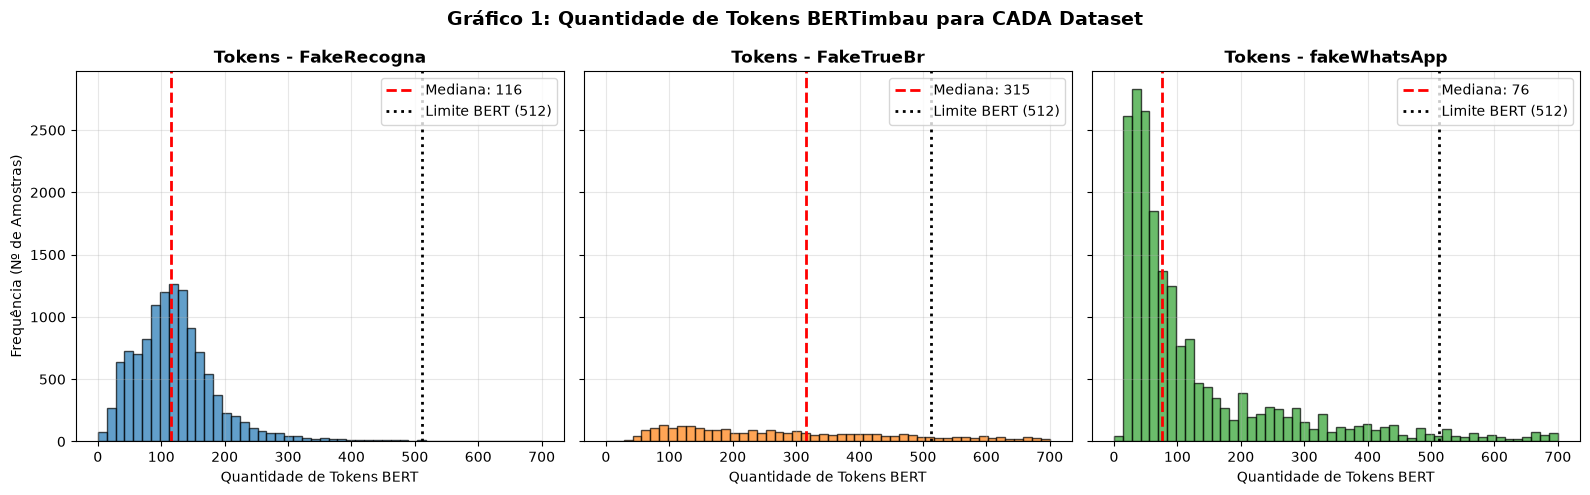

In [4]:
# GRÁFICO 1: Quantidade de Tokens para CADA Dataset
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
datasets_info = [('FakeRecogna', tok_r, colors[0]), ('FakeTrueBr', tok_ft, colors[1]), ('fakeWhatsApp', tok_w, colors[2])]

for i, (name, tok, col) in enumerate(datasets_info):
    axes[i].hist(tok, bins=50, range=(0, 700), color=col, alpha=0.7, edgecolor='black')
    axes[i].axvline(np.median(tok), color='red', linestyle='--', linewidth=2, label=f'Mediana: {np.median(tok):.0f}')
    axes[i].axvline(512, color='black', linestyle=':', linewidth=2, label='Limite BERT (512)')
    axes[i].set_title(f'Tokens - {name}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Quantidade de Tokens BERT')
    if i == 0:
        axes[i].set_ylabel('Frequência (Nº de Amostras)')
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Gráfico 1: Quantidade de Tokens BERTimbau para CADA Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

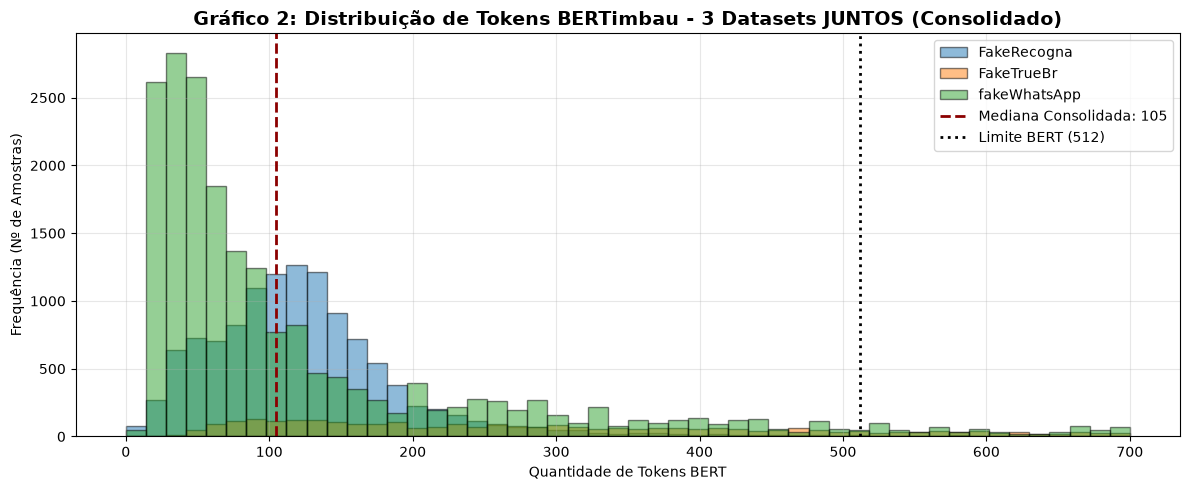

In [5]:
# GRÁFICO 2: Distribuição dos 3 Datasets JUNTOS (Consolidado)
plt.figure(figsize=(12, 5))
plt.hist(tok_r, bins=50, range=(0, 700), alpha=0.5, label='FakeRecogna', color='#1f77b4', edgecolor='black')
plt.hist(tok_ft, bins=50, range=(0, 700), alpha=0.5, label='FakeTrueBr', color='#ff7f0e', edgecolor='black')
plt.hist(tok_w, bins=50, range=(0, 700), alpha=0.5, label='fakeWhatsApp', color='#2ca02c', edgecolor='black')
plt.axvline(np.median(tok_consolidado), color='darkred', linestyle='--', linewidth=2, label=f'Mediana Consolidada: {np.median(tok_consolidado):.0f}')
plt.axvline(512, color='black', linestyle=':', linewidth=2, label='Limite BERT (512)')
plt.title('Gráfico 2: Distribuição de Tokens BERTimbau - 3 Datasets JUNTOS (Consolidado)', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade de Tokens BERT')
plt.ylabel('Frequência (Nº de Amostras)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 3. Contaminação Cruzada (Duplicatas entre Bases)


In [6]:
def norm(t):
    t = str(t).lower()
    t = re.sub(r'http\S+|www\S+', '', t)
    t = re.sub(r'[^\w\s]', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

fakes_r = list(df_r_norm[df_r_norm['label'] == 0]['text'].apply(norm).unique())
fakes_ft = list(df_ft_norm[df_ft_norm['label'] == 0]['text'].apply(norm).unique())
fakes_w = list(df_w_norm[df_w_norm['label'] == 0]['text'].apply(norm).unique())

vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.85)
X = vec.fit_transform(fakes_r + fakes_ft + fakes_w)
n_r, n_ft, n_w = len(fakes_r), len(fakes_ft), len(fakes_w)
X_r, X_ft, X_w = X[:n_r], X[n_r:n_r+n_ft], X[n_r+n_ft:]

quase_ft_w = int((cosine_similarity(X_ft, X_w) > 0.8).sum())
quase_r_ft = int((cosine_similarity(X_r, X_ft) > 0.8).sum())
quase_r_w = int((cosine_similarity(X_r, X_w) > 0.8).sum())
exatas = len(set(fakes_ft).intersection(set(fakes_w))) + len(set(fakes_r).intersection(set(fakes_ft))) + len(set(fakes_r).intersection(set(fakes_w)))
k_total = exatas + quase_ft_w + quase_r_ft + quase_r_w

print(f"Duplicatas Exatas de Fake News: {exatas}")
print(f"Quase-Duplicatas (>0.8 cosseno): FakeTrueBr x WhatsApp = {quase_ft_w} | Recogna x FakeTrueBr = {quase_r_ft}")
print(f"Total de sobreposição cruzada (K): K = {k_total} duplicatas/variantes")

Duplicatas Exatas de Fake News: 5
Quase-Duplicatas (>0.8 cosseno): FakeTrueBr x WhatsApp = 71 | Recogna x FakeTrueBr = 2
Total de sobreposição cruzada (K): K = 78 duplicatas/variantes


---
## 4. Tabela Comparativa Consolidada Final


In [7]:
tabela = pd.DataFrame([
    {"Métrica / Aspecto": "Total de Amostras", "Base 1 (FakeRecogna)": f"{len(df_r_norm):,}", "Base 2 (FakeTrueBr)": f"{len(df_ft_norm):,} ({len(df_ft):,} pares)", "Base 3 (fakeWhatsApp)": f"{len(df_w_norm):,} ({len(df_w_dedup):,} únicas)", "Consolidado": f"{len(tok_consolidado):,} (22,410 únicas)"},
    {"Métrica / Aspecto": "Proporção (Falso / Real)", "Base 1 (FakeRecogna)": "50.0% / 50.0%", "Base 2 (FakeTrueBr)": "50.0% / 50.0%", "Base 3 (fakeWhatsApp)": "53.6% / 46.4%", "Consolidado": "52.1% / 47.9%"},
    {"Métrica / Aspecto": "Mediana de Tokens BERT", "Base 1 (FakeRecogna)": f"{np.median(tok_r):.1f}", "Base 2 (FakeTrueBr)": f"{np.median(tok_ft):.1f}", "Base 3 (fakeWhatsApp)": f"{np.median(tok_w):.1f} ({np.median(tok_w_dedup):.1f} únicas)", "Consolidado": f"{np.median(tok_consolidado):.1f}"},
    {"Métrica / Aspecto": "Percentual >512 Tokens", "Base 1 (FakeRecogna)": f"{(tok_r > 512).mean()*100:.2f}%", "Base 2 (FakeTrueBr)": f"{(tok_ft > 512).mean()*100:.2f}%", "Base 3 (fakeWhatsApp)": f"{(tok_w > 512).mean()*100:.2f}%", "Consolidado": f"{(tok_consolidado > 512).mean()*100:.2f}%"},
    {"Métrica / Aspecto": "Origem do Texto", "Base 1 (FakeRecogna)": "Fact-checking + Web", "Base 2 (FakeTrueBr)": "Fact-checking (G1 / Boatos)", "Base 3 (fakeWhatsApp)": "Redes Sociais (WhatsApp)", "Consolidado": "Misto (Web, Checagem e Redes)"},
    {"Métrica / Aspecto": "Sobreposição de Textos", "Base 1 (FakeRecogna)": "—", "Base 2 (FakeTrueBr)": "—", "Base 3 (fakeWhatsApp)": "—", "Consolidado": f"5 exatas / 73 variantes (K = {k_total})"}
])
print(tabela.to_string(index=False))

       Métrica / Aspecto Base 1 (FakeRecogna)         Base 2 (FakeTrueBr)    Base 3 (fakeWhatsApp)                      Consolidado
       Total de Amostras               11,902         3,582 (1,791 pares)    21,289 (6,926 únicas)           36,773 (22,410 únicas)
Proporção (Falso / Real)        50.0% / 50.0%               50.0% / 50.0%            53.6% / 46.4%                    52.1% / 47.9%
  Mediana de Tokens BERT                116.0                       315.0       76.0 (81.0 únicas)                            105.0
  Percentual >512 Tokens                0.83%                      28.34%                    9.00%                            8.24%
         Origem do Texto  Fact-checking + Web Fact-checking (G1 / Boatos) Redes Sociais (WhatsApp)    Misto (Web, Checagem e Redes)
  Sobreposição de Textos                    —                           —                        — 5 exatas / 73 variantes (K = 78)
